In [105]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from numpy import percentile
import xarray as xr

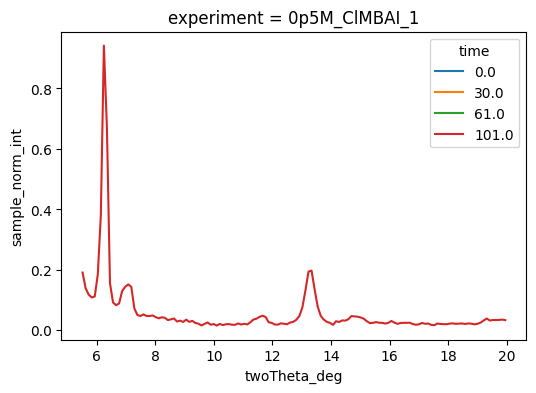

In [168]:
pdataset = xr.open_dataset(r"G:\Shared drives\Sutter-Fella Lab\ECRP-Project\results\beamtime_Dec2025\giwaxs_combined.nc")

pdataset = pdataset.swap_dims({"q_A^-1": "twoTheta_deg"})

sample_1 = pdataset.isel(experiment=1)

fig, ax = plt.subplots(figsize=(6,4))

sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 20)).sel(time=[0, 30, 60, 100], method='nearest').plot.line(x="twoTheta_deg", ax=ax)

Voigt Fit Parameters for peak at 7.80°:
  Amplitude: 0.637
  Center: 8.304°
  Sigma: 0.000
  Gamma: 1.028
  Slope: -0.127
  Offset: -0.138

Voigt Fit Parameters for peak at 8.12°:
  Amplitude: 0.000
  Center: 8.065°
  Sigma: 20.672
  Gamma: 20.508
  Slope: -0.029
  Offset: 0.078

Voigt Fit Parameters for peak at 10.10°:
  Amplitude: 0.003
  Center: 10.132°
  Sigma: 0.000
  Gamma: 0.085
  Slope: -0.000
  Offset: 0.055

Voigt Fit Parameters for peak at 11.35°:
  Amplitude: 0.004
  Center: 11.315°
  Sigma: 0.094
  Gamma: 0.000
  Slope: 0.000
  Offset: 0.046

Voigt Fit Parameters for peak at 13.23°:
  Amplitude: 0.211
  Center: 13.205°
  Sigma: 0.202
  Gamma: 0.000
  Slope: -0.000
  Offset: 0.072



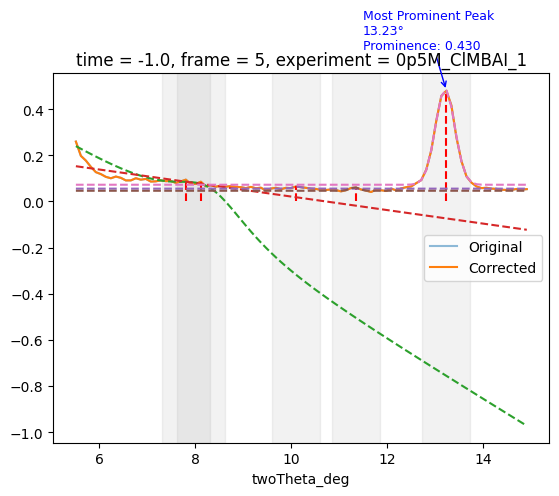

In [189]:
from spectral_analysis import voigt
import numpy as np
from scipy.signal import peak_widths, find_peaks
from scipy.optimize import curve_fit
from scipy.special import wofz
from pybaselines import Baseline
import xarray as xr

sample_1_da = sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 15)).dropna('time').sel(time=0, method='nearest')

# xarray da compatible baseline correction function
def baseline_correction(da: xr.DataArray, sample=None, method=None, **kwargs):
    """Perform baseline correction on an xarray DataArray using specified method.
    Parameters:
        da (xr.DataArray): Input data array to be baseline corrected.
        sample (str, optional): Type of sample to determine default method and parameters.
        method (str, optional): Baseline correction method to use.
    Returns:
        corrected_da (xr.DataArray): Baseline corrected data array.
        baseline_da (xr.DataArray): Calculated baseline data array.
    """

    if sample is not None and method is not None:
        raise ValueError("Either method or sample type must be specified, not both.")
    
    if method is None:
        if sample == "PXRD":
            method = "asls"
            kwargs = {"lam": 5e3}
        elif sample == "UV-Vis":
            method = "aspls"
            kwargs = {"lam": 7e5}
        else:
            raise ValueError("Unknown sample type. Please specify method directly.")
        
    baseline_finder = Baseline()
    func = getattr(baseline_finder, method)
    baseline, _ = func(da.values, **kwargs)
    corrected = da.values - baseline

    corrected_da = xr.DataArray(corrected, coords=da.coords, dims=da.dims)
    baseline_da = xr.DataArray(baseline, coords=da.coords, dims=da.dims)
    return corrected_da, baseline_da

corrected = sample_1_da.copy()

# corrected, calc_baseline = baseline_correction(sample_1_da, method='asls', lam=5e3)

# fig, ax = plt.subplots(figsize=(6,4))
sample_1_da.plot(label='Original', alpha=0.5)
corrected.plot(label='Corrected')
# calc_baseline.plot(label='Baseline', linestyle=':', alpha=0.7)
plt.legend()
# plt.ylim(None, 0.15)

# xarray da compatible peak peak fitting function
def find_peaks_in_window(da: xr.DataArray, x: str, target=None, window_size=None, **find_peaks_kwargs):

    if x not in da.dims and x not in da.coords:
        raise ValueError(f"{x} must be a dimension or coordinate in the DataArray.")

    if target is not None and window_size is not None:
        target_da = da.sel(**{x: slice(target - window_size / 2, target + window_size / 2)})
        da = target_da 
    
    peaks_indices, properties = find_peaks(da.values, **find_peaks_kwargs)

    # convert indices back to original x values (wavelength or twoTheta)
    peaks_x = da[x].values[peaks_indices]
    # get intensities at peak positions
    peaks_intensities = da.values[peaks_indices]

    # Convert properties from dict of arrays to array of dicts
    properties = [dict(zip(properties,t)) for t in zip(*properties.values())]

    return peaks_x, peaks_intensities, properties


peaks_x, peaks_intensities, properties = find_peaks_in_window(
    corrected,
    x="twoTheta_deg",
    # target=7.5,
    # window_size=2,
    height=0.01,
    prominence=0.01
)

plt.vlines(peaks_x, ymin=0, ymax=peaks_intensities, color='red', linestyle='--', label='Detected Peaks')
# print peak positions and properties

# for x, intensity, prop in zip(peaks_x, peaks_intensities, properties):
#     # print every property as .3f
#     text = [f"{key}: {value:.3f}" for key, value in prop.items()]
#     plt.annotate(
#         f"{x:.2f}°\n" + "\n".join(text),
#         xy=(x,intensity),
#         xytext=(5,0),
#         textcoords='offset points',
#         ha='left',
#         va='bottom' if intensity < 0.2 else 'center',
#         fontsize=8,
#         color='red'
#     )

# get the most prominent peak
if properties:
    prominences = [prop['prominences'] for prop in properties]
    max_prom_idx = np.argmax(prominences)
    peak_pos = peaks_x[max_prom_idx]
    peak_intensity = peaks_intensities[max_prom_idx]
    plt.annotate(
        f"Most Prominent Peak\n{peak_pos:.2f}°\nProminence: {prominences[max_prom_idx]:.3f}",
        xy=(peak_pos, max(0.2, peak_intensity)),
        xytext=(-60,30),
        textcoords='offset points',
        ha='left',
        fontsize=9,
        color='blue',
        arrowprops=dict(arrowstyle='->', color='blue')
    )

# Define the Voigt profile function globally for use in area calculation
def voigt_profile_func(x, amp, cen, sigma, gamma, slope, offset):
    z = ((x - cen) + 1j * gamma) / (sigma * np.sqrt(2))
    return amp * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + slope * (x-cen) + offset

# xarray da compatible peak fitting function
def voigt_fit(da: xr.DataArray, x: str, peak_pos: float, window_size: float, no_slope=True):
    
    # set bounds for parameters: amp > 0, sigma > 0, gamma > 0
    # amp, cen, sigma, gamma, slope, offset
    if no_slope:
        bounds = (
            [0, peak_pos - 0.5, 0, 0, -1e-9, -np.inf], 
            [np.inf, peak_pos + 0.5, np.inf, np.inf, 1e-9, np.inf]
        )
    else:
        bounds = (
            [0, peak_pos - 0.5, 0, 0, -np.inf, -np.inf], 
            [np.inf, peak_pos + 0.5, np.inf, np.inf, np.inf, np.inf]
        )

    peak_intensity = da.sel(**{x: peak_pos}, method='nearest').values
    fit_da = da.sel(**{x: slice(peak_pos - window_size / 2, peak_pos + window_size / 2)})
    x_data = fit_da[x].values
    y_data = fit_da.values

    # guess: amp, cen, sigma, gamma, slope, offset
    initial_guess = [peak_intensity, peak_pos, 0.1, 0.1, 0, np.min(y_data)]
    popt, pcov = curve_fit(voigt_profile_func, x_data, y_data, p0=initial_guess, bounds=bounds)

    fitted_curve = voigt_profile_func(da[x].values, *popt)
    fitted_da = xr.DataArray(fitted_curve, coords=da.coords, dims=da.dims)

    return fitted_da, popt

fitted_das = []
for peak_pos in peaks_x:
    try:
        no_slope = peak_pos > 10.0 
        fitted_da, popt = voigt_fit(corrected, x="twoTheta_deg", peak_pos=peak_pos, window_size=0.9, no_slope=no_slope)
        fitted_das.append(fitted_da)
    except RuntimeError:
        print(f"Voigt fit failed for peak at {peak_pos:.2f}°")
        continue
    fitted_da.plot(label=f'Voigt Fit at {peak_pos:.2f}°', linestyle='--')
    # print every property as .3f
    amp, cen, sigma, gamma, slope, offset = popt
    print(
        f"Voigt Fit Parameters for peak at {peak_pos:.2f}°:\n"
        f"  Amplitude: {amp:.3f}\n"
        f"  Center: {cen:.3f}°\n"
        f"  Sigma: {sigma:.3f}\n"
        f"  Gamma: {gamma:.3f}\n"
        f"  Slope: {slope:.3f}\n"
        f"  Offset: {offset:.3f}\n"
    )
    plt.axvspan(peak_pos - 0.5, peak_pos + 0.5, color='gray', alpha=0.1)

# plt the sum of fitted peaks along twoTheta
# sum_fitted = sum(fitted_das)
# sum_fitted.plot(label='Sum of Voigt Fits', color='black', linewidth=2)




# plt.plot(sample_1_da.twoTheta_deg, sample_1_da, label='Original')
# plt.plot(sample_1_da.twoTheta_deg, corrected, label='Corrected')
# plt.plot(sample_1_da.twoTheta_deg, calc_baseline, label='Baseline', linestyle=':')
# plt.ylim(None, 0.2)

In [4]:
corrected.sel(twoTheta_deg=slice(5.5141, 8.38))["twoTheta_deg"].values

array([5.61809268, 5.7221391 , 5.82619025, 5.9302462 , 6.03430705,
       6.13837287, 6.24244377, 6.34651982, 6.45060111, 6.55468773,
       6.65877976, 6.76287729, 6.86698041, 6.97108921, 7.07520376,
       7.17932417, 7.28345051, 7.38758287, 7.49172134, 7.59586601,
       7.70001696, 7.80417428, 7.90833806, 8.01250839, 8.11668535,
       8.22086903, 8.32505951])

In [5]:
corrected["twoTheta_deg"].values

array([ 5.51405089,  5.61809268,  5.7221391 ,  5.82619025,  5.9302462 ,
        6.03430705,  6.13837287,  6.24244377,  6.34651982,  6.45060111,
        6.55468773,  6.65877976,  6.76287729,  6.86698041,  6.97108921,
        7.07520376,  7.17932417,  7.28345051,  7.38758287,  7.49172134,
        7.59586601,  7.70001696,  7.80417428,  7.90833806,  8.01250839,
        8.11668535,  8.22086903,  8.32505951,  8.42925689,  8.53346126,
        8.63767269,  8.74189128,  8.84611712,  8.95035029,  9.05459088,
        9.15883898,  9.26309468,  9.36735806,  9.47162921,  9.57590823,
        9.68019519,  9.78449019,  9.88879332,  9.99310466, 10.0974243 ,
       10.20175234, 10.30608885, 10.41043393, 10.51478767, 10.61915015,
       10.72352147, 10.82790171, 10.93229096, 11.03668931, 11.14109685,
       11.24551367, 11.34993986, 11.45437551, 11.5588207 , 11.66327553,
       11.76774008, 11.87221445, 11.97669873, 12.08119299, 12.18569735,
       12.29021187, 12.39473667, 12.49927181, 12.6038174 , 12.70

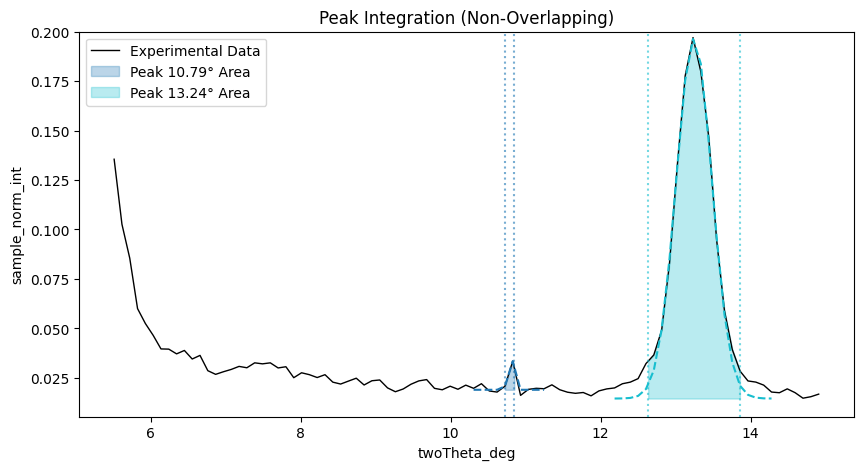

Peak Center  Area         Integration Range         Offset    
-----------------------------------------------------------------
10.787       0.00110      [10.726, 10.848]          0.019     
13.245       0.10937      [12.634, 13.856]          0.015     


In [136]:
from scipy.optimize import brentq
from scipy.special import wofz
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

def get_confidence_bounds(amp, cen, sigma, gamma, confidence=0.95, cut_off=2):
    """
    Calculate the x-values that bound `confidence` (fraction) of the Voigt profile area.
    Default is 0.95 (95%).
    
    Parameters:
    ----------
    amp : float
        Amplitude of the Voigt profile.
    cen : float
        Center of the Voigt profile.
    sigma : float
        Gaussian width parameter.
    gamma : float
        Lorentzian width parameter.
    confidence : float
        Fraction of area to include between bounds (default 0.95).
    cut_off : float
        Multiplier for FWHM to limit bounds (default 2).
        
    Returns:
    -------
    l : float
        Left bound x-value.
    r : float
        Right bound x-value.
    """
    # Estimate FWHM to define a sufficient grid
    fwhm_L = 2 * gamma
    fwhm_G = 2.3548 * sigma
    fwhm = 0.5346 * fwhm_L + np.sqrt(0.2166 * fwhm_L**2 + fwhm_G**2)
    
    # Create a grid wide enough to capture the tails (20 * FWHM)
    window = 20 * fwhm
    # Handle single point or zero width cases to avoid linspace errors
    if window == 0: window = 1.0 
    
    x_grid = np.linspace(cen - window, cen + window, 5000)
    
    # Calculate profile without background (slope=0, offset=0) for area distribution
    y_grid = voigt_profile_func(x_grid, amp, cen, sigma, gamma, 0, 0)
    
    # Cumulative area
    cum_area = np.cumsum(y_grid) * (x_grid[1] - x_grid[0])
    # Protect against div by zero if flat
    total_area = cum_area[-1]
    if total_area == 0:
        return cen - 0.1, cen + 0.1
    
    # Calculate quantiles based on confidence level
    alpha = 1.0 - confidence
    lower_q = alpha / 2.0
    upper_q = 1.0 - (alpha / 2.0)
    
    # Find indices for lower and upper quantiles
    norm_cum = cum_area / total_area
    idx_low = np.searchsorted(norm_cum, lower_q)
    idx_high = np.searchsorted(norm_cum, upper_q)

    l, r = x_grid[idx_low], x_grid[idx_high]

    # Clip to reasonable range around center (prevent runaway bounds)
    l, r = np.clip(l, cen - cut_off * fwhm, cen), np.clip(r, cen, cen + cut_off * fwhm)
    
    return l, r

def calculate_peak_areas(da: xr.DataArray, x: str, fit_results: list, confidence=0.95, tolerance=0.025, integration_max_span=3.0):
    """
    Calculate peak areas.
    Boundaries:
    - Between peaks: Intersection of fitted Voigt curves (pure profile, excluding background).
    - Outer edges (or single peak): Bounds containing `confidence` fraction of the fitted Voigt area.
    
    Parameters:
    -----------
    da : xr.DataArray
        The input data array.
    x : str
        Dimension name.
    fit_results : list
        List of dicts with 'popt'.
    confidence : float
        Fraction of area to include for outer boundaries (default 0.95).
    tolerance : float
        Tolerance for matching integration limits to data points (default 0.025).
    integration_max_span : float
        Maximum allowed span for integration limits (default 3.0).
        
    Returns:
    --------
    processed_results : list
        List of dicts with added 'area', 'integration_range', 'offset_used', and 'slope_used'.
    """
    
    # Sort results by peak center
    sorted_results = sorted(fit_results, key=lambda r: r['popt'][1])
    processed_results = []
    
    # Range of data for integration limits
    x_min, x_max = da[x].min().item(), da[x].max().item()

    # Pre-calculate intersections between all adjacent pairs
    # intersections[i] is the boundary between peak i and peak i+1
    intersections = {}
    
    for i in range(len(sorted_results) - 1):
        popt_curr = sorted_results[i]['popt']
        popt_next = sorted_results[i+1]['popt']
        
        # Unpack pure profile params
        if len(popt_curr) == 6:
            c_amp, c_cen, c_sigma, c_gamma = popt_curr[:4]
        else:
            c_amp, c_cen, c_sigma, c_gamma = popt_curr[:4]
            
        if len(popt_next) == 6:
            n_amp, n_cen, n_sigma, n_gamma = popt_next[:4]
        else:
            n_amp, n_cen, n_sigma, n_gamma = popt_next[:4]

        def diff_func(val):
            val_curr = voigt_profile_func(val, c_amp, c_cen, c_sigma, c_gamma, 0, 0)
            val_next = voigt_profile_func(val, n_amp, n_cen, n_sigma, n_gamma, 0, 0)
            return val_curr - val_next
        
        try:
            root = brentq(diff_func, c_cen, n_cen)
            intersections[i] = root
        except ValueError:
            # If they don't intersect between centers, pick midpoint or use confidence
            # A safe fallback is the midpoint for strict separation
            intersections[i] = (c_cen + n_cen) / 2

    for i, res in enumerate(sorted_results):
        popt = res['popt']
        if len(popt) == 6:
            amp, cen, sigma, gamma, slope, offset = popt
        else:
            amp, cen, sigma, gamma = popt[:4]
            slope, offset = 0, 0
            
        # Get purely statistical confidence bounds
        l_conf, r_conf = get_confidence_bounds(amp, cen, sigma, gamma, confidence=confidence)
        
        # --- LEFT BOUNDARY ---
        if i == 0:
            # First peak: use confidence bound, limited by data
            l_final = max(l_conf, x_min)
        else:
            # Use intersection with previous peak
            # Constraint: It cannot be further left than the intersection
            # It CAN be further right if confidence bound is tighter (narrow peak)
            intersect_prev = intersections[i-1]
            l_final = max(intersect_prev, l_conf)

        # --- RIGHT BOUNDARY ---
        if i == len(sorted_results) - 1:
            # Last peak: use confidence bound, limited by data
            r_final = min(r_conf, x_max)
        else:
            # Use intersection with next peak
            # Constraint: It cannot be further right than the intersection
            # It CAN be further left if confidence bound is tighter
            intersect_next = intersections[i]
            r_final = min(intersect_next, r_conf)

        # --- MAX SPAN SAFETY CHECK ---
        # Only apply max span if it shrinks the range towards the center
        # This keeps bounds centered but respecting neighbors if they are close
        if (r_final - l_final) > integration_max_span:
            # If too wide, shrink symmetrically from center, but don't cross intersections
            half_span = integration_max_span / 2
            
            # Propose new bounds
            l_prop = cen - half_span
            r_prop = cen + half_span
            
            # Apply intersection constraints again
            if i > 0: l_prop = max(l_prop, intersections[i-1])
            if i < len(sorted_results) - 1: r_prop = min(r_prop, intersections[i])
            
            l_final, r_final = l_prop, r_prop

        # --- VALIDATE ORDER ---
        if l_final >= r_final:
            # Fallback if logic compressed it to nothing (rare)
            l_final = cen - 0.05
            r_final = cen + 0.05

        # Get exact data indices
        l_integ = max(l_final, x_min)
        r_integ = min(r_final, x_max)

        # Area Integration
        subset_x = da.sel(**{x: slice(l_integ, r_integ)})[x].values
        
        # Check if we need interpolation for smoother boundaries
        if len(subset_x) < 2 or np.abs(subset_x[0] - l_integ) > tolerance or np.abs(subset_x[-1] - r_integ) > tolerance:
             # Create inclusive grid
             grid_x = np.unique(np.concatenate(([l_integ], subset_x, [r_integ])))
             grid_x = grid_x[(grid_x >= l_integ) & (grid_x <= r_integ)] # Clean sort
             
             if len(grid_x) > 1:
                 # Interpolate data onto this grid
                 extended_y = da.interp({x: grid_x}).values
                 subset = xr.DataArray(extended_y, coords={x: grid_x}, dims=[x])
             else:
                 subset = xr.DataArray([], coords={x: []}, dims=[x])
        else:
            subset = da.sel(**{x: subset_x})
            
        if subset.sizes[x] > 1:
            # Subtract baseline
            # Background = slope * (x - cen) + offset
            background = slope * (subset[x] - cen) + offset
            corrected_subset = subset - background
            
            area = corrected_subset.integrate(coord=x).item()
        else:
            area = 0.0

        res_copy = res.copy()
        res_copy.update({
            'area': area,
            'integration_range': (l_integ, r_integ),
            'offset_used': offset,
            'slope_used': slope
        })
        processed_results.append(res_copy)

    return processed_results

# --- Usage (Re-run) ---

# 1. Collect fit results
collected_results = []
# print("Fitting peaks for area calculation...")
for peak_pos in peaks_x:
    try:
        no_slope = peak_pos > 10.0
        fitted_da, popt = voigt_fit(corrected, x="twoTheta_deg", peak_pos=peak_pos, window_size=0.9, no_slope=no_slope)
        collected_results.append({'popt': popt, 'peak_pos': peak_pos})
    except RuntimeError:
        pass

# 2. Calculate areas (using 95% confidence)
areas_info = calculate_peak_areas(corrected, "twoTheta_deg", collected_results, confidence=0.99)

# 3. Visualization
plt.figure(figsize=(10, 5))
corrected.plot(label='Experimental Data', color='black', linewidth=1)

colors = plt.cm.tab10(np.linspace(0, 1, len(areas_info)))

for i, info in enumerate(areas_info):
    l, r = info['integration_range']
    cen = info['popt'][1]
    
    if len(info['popt']) == 6:
        offset = info['popt'][5] 
        slope = info['popt'][4]
    else:
        offset = 0
        slope = 0
        
    background_func = lambda x: slope * (x - cen) + offset

    color = colors[i]
    
    # Plot boundaries
    plt.axvline(l, linestyle=':', color=color, alpha=0.6)
    plt.axvline(r, linestyle=':', color=color, alpha=0.6)

    # Re-construct subset for plotting fill
    grid_x = np.linspace(l, r, 100) # simpler for plotting
    grid_y_data = corrected.interp({"twoTheta_deg": grid_x}).values
    subset = xr.DataArray(grid_y_data, coords={"twoTheta_deg": grid_x}, dims=["twoTheta_deg"])
    
    # Shade integration area (data - background)
    bg_vals = background_func(subset.twoTheta_deg)
    
    plt.fill_between(subset.twoTheta_deg, subset, bg_vals, 
                     where=(subset > bg_vals),
                     alpha=0.3, color=color, label=f'Peak {cen:.2f}° Area')
    
    # plot the fitted Voigt profile
    subset_x_fit = corrected.sel(**{"twoTheta_deg": slice(l-0.5, r+0.5)})["twoTheta_deg"].values
    if len(subset_x_fit) > 0:
        fitted_curve = voigt_profile_func(subset_x_fit, *info['popt'])
        plt.plot(subset_x_fit, fitted_curve, linestyle='--', color=color)

plt.legend()
plt.title("Peak Integration (Non-Overlapping)")
plt.ylim(None, 0.2)
plt.show()

# 4. Print Results
print(f"{'Peak Center':<12} {'Area':<12} {'Integration Range':<25} {'Offset':<10}")
print("-" * 65)
for info in areas_info:
    l, r = info['integration_range']
    if len(info['popt']) == 6:
        off = info['popt'][5]
    else:
        off = 0
    print(f"{info['popt'][1]:<12.3f} {info['area']:<12.5f} {f'[{l:.3f}, {r:.3f}]':<25} {off:<10.3f}")

In [34]:
sample_1 = pdataset.isel(experiment=2)

# 1. Select the time series data
time_series_da = sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 20)).sel(time=slice(0, 300))
times = time_series_da.time.values

sample_1_da = time_series_da.sel(time=1, method='nearest')

corrected, calc_baseline = baseline_correction(sample_1_da, method='asls', lam=5e3)

peaks_x, peaks_intensities, properties = find_peaks_in_window(
    corrected,
    x="twoTheta_deg",
    # target=7.5,
    # window_size=2,
    height=0.01,
    prominence=0.005
)

print(f"Identified peaks at positions: {peaks_x}")

Identified peaks at positions: [10.82790171 13.23131532]


In [70]:
pdataset.experiment.values

array(['0p1M_ClMBAI_1', '0p5M_ClMBAI_1', '0p5M_MBAI_1', '0p5M_pMeOMBAI_1',
       '1p0M_ClMBAI_1', '1p0M_pMeOMBAI_1', '1p5M_ClMBAI_1',
       '1p5M_pMeOMBAI_1', 'insitu_0p5M_MeOMBAI_7',
       'insitu_1p0M_ClMBAI_6re', 'insitu_1p0M_MBAI_5',
       'insitu_1p0M_MeOMBAI_6'], dtype=object)

In [190]:
# --- Time Series Analysis ---
from turtle import width
import pandas as pd
import matplotlib.pyplot as plt

sample_1 = pdataset.isel(experiment=1)

# 1. Select the time series data
time_series_da = sample_1["sample_norm_int"].sel(twoTheta_deg=slice(5.5, 20)).sel(time=slice(None, 300)).dropna(dim="time")
times = time_series_da.time.values

# Defined peaks of interest: (center_position, window_size)
# peaks_of_interest = [(6.9, 2), (13.3, 2)] # MBAI
peaks_of_interest = [(6.1, 2), (13.3, 2)] # ClMBAI
shift_threshold = 0.3

# Initialize storage for all detected peaks
all_peak_data = []

print(f"Processing {len(times)} time steps...")

for t in times:
    # A. Select Data for current time step
    da_t = time_series_da.sel(time=t, method='nearest')
    
    try:
        # B. Baseline Correction
        # corrected_t, _ = baseline_correction(da_t, method='asls', lam=5e3)
        corrected_t = da_t.copy()  # Assuming already baseline corrected for speed in this example
        
        # C. Use predefined peaks of interest
        current_step_fits = []
        # Keep track of which target peak corresponds to which fit result for shift checking
        target_positions = [] 

        for peak_pos, window_size in peaks_of_interest:
            try:
                peaks_x, intensity, _ = find_peaks_in_window(
                    corrected_t,
                    x="twoTheta_deg",
                    target=peak_pos,
                    window_size=window_size,
                    height=0.01,
                    prominence=0.01
                )
                if len(peaks_x) == 0:
                    continue
                peak_x = peaks_x[np.argmax(intensity)]  # Pick the most intense peak in the window
                # Fit peak at the specific position
                no_slope = peak_pos > 10.0
                _, popt = voigt_fit(corrected_t, x="twoTheta_deg", peak_pos=peak_x, window_size=window_size, no_slope=no_slope)
                # Validate fit amplitude
                if popt[0] < 0.01:
                    continue
                current_step_fits.append({'popt': popt})
                target_positions.append(peak_pos)
            except Exception:
                pass

        # D. Calculate Areas
        if current_step_fits:
            areas_info = calculate_peak_areas(corrected_t, "twoTheta_deg", current_step_fits, confidence=0.95)
            
            # Check for shifts and visualize if needed
            visualize_step = False
            large_shifts = []
            
            # Note: areas_info is sorted by peak center, so we need to match it back to targets carefully if order changed
            # But usually they stay in relatively same order. A simple heuristic is comparing to targets.
            
            for info in areas_info:
                fitted_center = info['popt'][1]
                
                # storage
                all_peak_data.append({
                    'Time': t,
                    'Position': fitted_center,
                    'Area': info['area']
                })
                
                # Check deviation from *any* target (finding the closest one)
                shifts = [np.abs(fitted_center - target) for target in [p[0] for p in peaks_of_interest]]
                min_shift = min(shifts)
                
                if min_shift > shift_threshold:
                    visualize_step = True
                    closest_target = [p[0] for p in peaks_of_interest][np.argmin(shifts)]
                    large_shifts.append(f"Peak {closest_target}° -> {fitted_center:.3f}° (shift {min_shift:.3f})")

            if visualize_step:
                print(f"Key Step Detected at Time {t}s due to shifts: {', '.join(large_shifts)}")
                
                plt.figure(figsize=(10, 4))
                corrected_t.plot(label='Data', color='black', linewidth=1)
                
                colors = plt.cm.tab10(np.linspace(0, 1, len(areas_info)))
                
                for i, info in enumerate(areas_info):
                    l, r = info['integration_range']
                    cen = info['popt'][1]
                    
                    if len(info['popt']) == 6:
                        offset = info['popt'][5] 
                        slope = info['popt'][4]
                    else:
                        offset = 0
                        slope = 0
                    
                    background_func = lambda x: slope * (x - cen) + offset
                    
                    color = colors[i]
                    
                    # Fill area
                    subset_x = corrected_t.sel(twoTheta_deg=slice(l, r))
                    if len(subset_x) > 1:
                        bg_vals = background_func(subset_x.twoTheta_deg)
                        plt.fill_between(subset_x.twoTheta_deg, subset_x, bg_vals, 
                                         where=(subset_x > bg_vals),
                                         alpha=0.3, color=color)
                    
                    # Fit
                    fit_x = corrected_t.sel(twoTheta_deg=slice(cen-1, cen+1)).twoTheta_deg.values
                    if len(fit_x) > 0:
                        y_fit = voigt_profile_func(fit_x, *info['popt'])
                        plt.plot(fit_x, y_fit, '--', color=color, alpha=0.8)
                        # popt parameters as text
                        amp, cen, sigma, gamma = info['popt'][:4]
                        text = (f"Amp: {amp:.2f}\nCen: {cen:.2f}\n"
                                f"Sigma: {sigma:.3f}\nGamma: {gamma:.3f}")
                        plt.text(cen, max(y_fit)*0.9, text, color=color, fontsize=8, ha='center')

                        
                    plt.axvline(l, linestyle=':', color=color, alpha=0.5)
                    plt.axvline(r, linestyle=':', color=color, alpha=0.5)

                plt.title(f"Shift Detected at t={t}s")
                plt.ylim(None, 0.2) # Adjust based on data scale
                plt.show()

                
    except Exception as e:
        print(f"Error at time {t}: {e}")

# Convert results to DataFrame and restructure
if all_peak_data:
    df_raw = pd.DataFrame(all_peak_data)
    
    # Identify distinct peaks by grouping close positions
    # Rounding to 1 decimal place (~0.1 deg bin) usually works for distinct peaks
    df_raw['PeakBin'] = df_raw['Position'].round(1)
    
    # Pivot table: Index=Time, Columns=PeakBin (Center), Values=Area
    df_evolution = df_raw.pivot_table(index='Time', columns='PeakBin', values='Area')
    df_evolution.columns.name = 'Peak Center'
    
    # Sort columns by peak position
    df_evolution = df_evolution.sort_index(axis=1)
else:
    df_evolution = pd.DataFrame()

# Display first few rows
print(df_evolution.head())

Processing 124 time steps...
Peak Center  6.2   6.3       13.1      13.2  13.3
Time                                             
-9.0          NaN   NaN  0.228703       NaN   NaN
-7.0          NaN   NaN  0.228746       NaN   NaN
-5.0          NaN   NaN       NaN  0.237791   NaN
-3.0          NaN   NaN       NaN  0.241895   NaN
-1.0          NaN   NaN       NaN  0.244364   NaN
Peak Center  6.2   6.3       13.1      13.2  13.3
Time                                             
-9.0          NaN   NaN  0.228703       NaN   NaN
-7.0          NaN   NaN  0.228746       NaN   NaN
-5.0          NaN   NaN       NaN  0.237791   NaN
-3.0          NaN   NaN       NaN  0.241895   NaN
-1.0          NaN   NaN       NaN  0.244364   NaN


In [191]:
df_evolution

Peak Center,6.2,6.3,13.1,13.2,13.3
Time,,,,,
-9.0,NaN,NaN,0.228703,NaN,NaN
-7.0,NaN,NaN,0.228746,NaN,NaN
-5.0,NaN,NaN,NaN,0.237791,NaN
-3.0,NaN,NaN,NaN,0.241895,NaN
-1.0,NaN,NaN,NaN,0.244364,NaN
...,...,...,...,...,...
291.0,NaN,0.159480,NaN,NaN,0.098158
293.0,NaN,0.158379,NaN,NaN,0.095128
295.0,NaN,0.160823,NaN,NaN,0.096530


In [192]:
# Postprocessing: Merge peaks that are very close in position
def merge_close_peaks(df: pd.DataFrame, threshold: float = 0.2) -> pd.DataFrame:
    """
    Merge peaks in the DataFrame that are closer than the specified threshold using chaining logic.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with peak areas, columns are peak centers.
    threshold : float
        Maximum distance between *adjacent* peaks to consider for merging.
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with merged peaks.
    """
    if df.empty:
        return df

    peak_centers = sorted(df.columns.values)
    to_merge = []
    
    # Initialize first group
    current_group = [peak_centers[0]]
    
    for k in range(1, len(peak_centers)):
        center = peak_centers[k]
        prev_in_group = current_group[-1]
        
        # Check distance to the last peak in the current group (chaining)
        if (center - prev_in_group) < threshold:
            current_group.append(center)
        else:
            # Close current group and start new one
            to_merge.append(current_group)
            current_group = [center]
            
    # Append the last group
    if current_group:
        to_merge.append(current_group)
    
    # Create new DataFrame with merged peaks
    df_merged = pd.DataFrame(index=df.index)
    
    for group in to_merge:
        # Define new center name (mean of the group)
        new_center = np.round(np.mean(group), 3)
        
        if len(group) > 1:
            print(f"Merging peaks {group} -> {new_center}")
            # Sum areas, preserving NaNs if all are NaN
            df_merged[new_center] = df[group].sum(axis=1, min_count=1)
        else:
            # print(f"Keeping peak at {group[0]} as is.")
            df_merged[new_center] = df[group[0]]
    
    # Sort columns for cleaner look
    df_merged = df_merged.sort_index(axis=1)
    
    return df_merged

df_final = merge_close_peaks(df_evolution, threshold=0.2)
print("Merged DataFrame Columns:", df_final.columns.values)
df_final.head()

Merging peaks [np.float64(6.2), np.float64(6.3)] -> 6.25
Merging peaks [np.float64(13.1), np.float64(13.2), np.float64(13.3)] -> 13.2
Merged DataFrame Columns: [ 6.25 13.2 ]


,6.25,13.20
Time,,
-9.0,NaN,0.228703
-7.0,NaN,0.228746
-5.0,NaN,0.237791
-3.0,NaN,0.241895
-1.0,NaN,0.244364


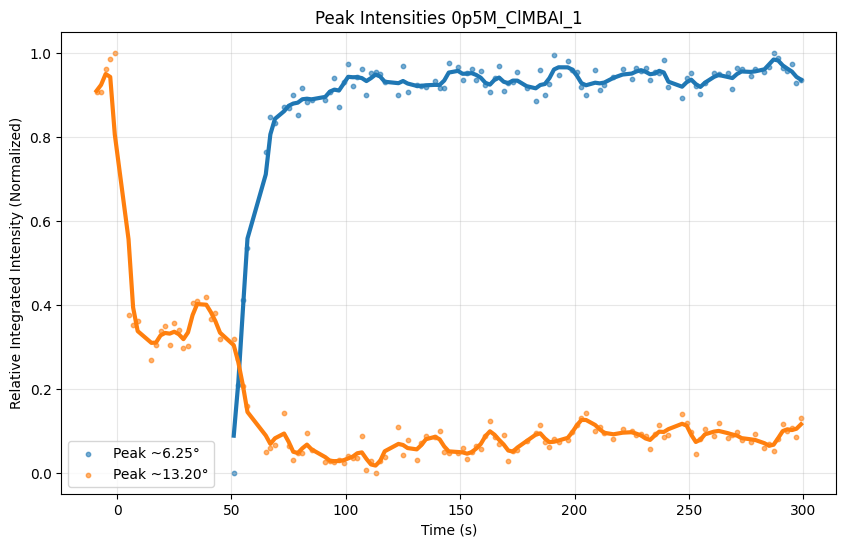

In [193]:


# 2. Plotting Normalized Time Series
plt.figure(figsize=(10, 6))

for peak_pos in df_final.columns:
    # Get the series for this peak
    peak_series = df_final[peak_pos]
    
    # Remove NaNs before plotting
    clean_series = peak_series.dropna()
    
    if not clean_series.empty:
        # Normalize to max intensity
        max_val = clean_series.max()
        min_val = clean_series.min()
        if max_val > 0:
            norm_series = (clean_series-min_val) / (max_val-min_val)
            label_str = f"Peak ~{peak_pos:.2f}°"
            plt.scatter(norm_series.index, norm_series.values, label=label_str, s=10, alpha=0.6)
            # plot gaussian smoothed line
            from scipy.ndimage import gaussian_filter1d
            smoothed = gaussian_filter1d(norm_series.values, sigma=1)
            plt.plot(norm_series.index, smoothed, linewidth=3)
    
plt.xlabel("Time (s)")
plt.ylabel("Relative Integrated Intensity (Normalized)")
plt.title(f"Peak Intensities {sample_1.experiment.values}",)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

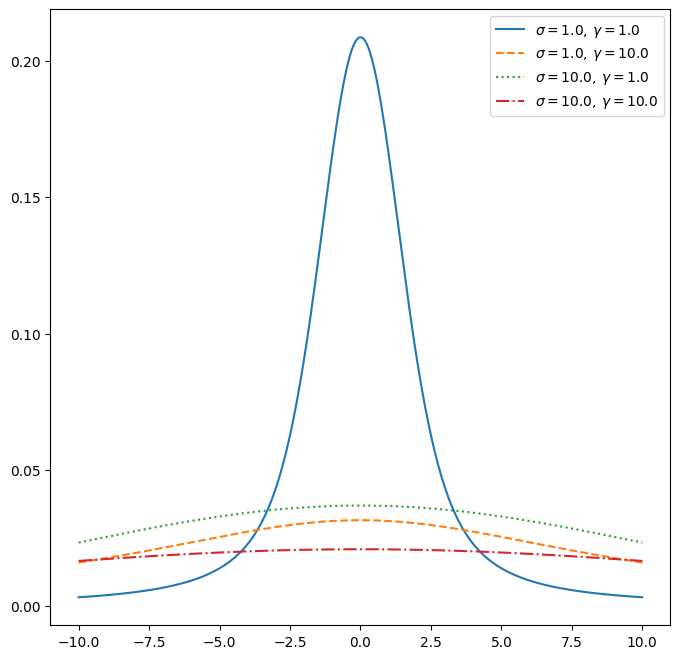

In [179]:
from scipy.special import voigt_profile
import numpy as np
import matplotlib.pyplot as plt
voigt_profile(2, 1., 1.)

fig, ax = plt.subplots(figsize=(8, 8))
x = np.linspace(-10, 10, 500)
parameters_list = [(1., 1., "solid"), (1., 10., "dashed"),
                   (10., 1., "dotted"), (10., 10., "dashdot")]
for params in parameters_list:
    sigma, gamma, linestyle = params
    voigt = voigt_profile(x, sigma, gamma)
    ax.plot(x, voigt, label=rf"$\sigma={sigma},\, \gamma={gamma}$",
            ls=linestyle)
ax.legend()
plt.show()